In [3]:
# Execute esta célula no Google Colab para instalar as dependências
!pip install pillow numpy pandas openpyxl matplotlib -q

Saving l-a8c2bebd49d846a89f1c9ff9691290fb.jpeg to l-a8c2bebd49d846a89f1c9ff9691290fb (3).jpeg
Imagem original: (1200, 1200)
Imagem redimensionada: (120, 120)
Matriz: (120, 120, 3)
✅ Excel salvo em: pixels.xlsx
✅ CSV salvo em:   pixels.csv


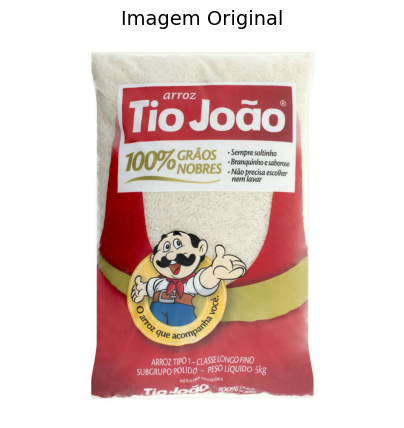

In [8]:
# ============================================================
# IMAGEM -> MATRIZ -> EXCEL/GOOGLE SHEETS
# ============================================================
# Requisitos:
# pip install pillow numpy pandas openpyxl
#
# No Google Colab, rode:
# !pip install pillow numpy pandas openpyxl
# ============================================================

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# ============================================================
# 1) FUNÇÃO: carregar imagem
# ============================================================

def load_image(path=None, use_colab_upload=True):

    if use_colab_upload:
        from google.colab import files
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        path = filename

    if path is None:
        raise ValueError("Você precisa fornecer um path ou usar use_colab_upload=True")

    img = Image.open(path).convert("RGB")  # força RGB (3 canais)
    return img


# ============================================================
# 2) FUNÇÃO: converter imagem em matriz
# ============================================================

def image_to_matrix(img):

    return np.array(img)


# ============================================================
# 3) FUNÇÃO: reduzir imagem (para não explodir a planilha)
# ============================================================

def resize_image(img, max_width=150, max_height=150):

    w, h = img.size

    scale = min(max_width / w, max_height / h, 1.0)
    new_w = int(w * scale)
    new_h = int(h * scale)

    return img.resize((new_w, new_h))


# ============================================================
# 4) FUNÇÃO: transformar pixels em tabela (cada célula = 1 pixel)
# ============================================================

def pixels_to_table(matrix):

    h, w, _ = matrix.shape

    # Cria uma matriz de strings (H x W)
    table = np.empty((h, w), dtype=object)

    for y in range(h):
        for x in range(w):
            r, g, b = matrix[y, x]
            table[y, x] = f"{r},{g},{b}"

    df = pd.DataFrame(table)
    return df


# ============================================================
# 5) FUNÇÃO: exportar para Excel e CSV
# ============================================================

def export_table(df, excel_path="pixels.xlsx", csv_path="pixels.csv"):

    df.to_excel(excel_path, index=False, header=False)
    df.to_csv(csv_path, index=False, header=False)

    print(f"✅ Excel salvo em: {excel_path}")
    print(f"✅ CSV salvo em:   {csv_path}")


# ============================================================
# 6) EXECUÇÃO PRINCIPAL
# ============================================================

if __name__ == "__main__":

    # ====== CONFIGURAÇÕES ======
    # Se estiver no Colab: coloque True
    USE_COLAB_UPLOAD = True

    # Se estiver no VSCode/local: coloque o caminho da imagem aqui
    IMAGE_PATH = "minha_imagem.png"

    # Limites (quanto maior, mais pesado)
    MAX_W = 120
    MAX_H = 120

    # ===========================

    img = load_image(path=IMAGE_PATH, use_colab_upload=USE_COLAB_UPLOAD)

    print("Imagem original:", img.size)

    # Reduz para não travar Excel/Sheets
    img_small = resize_image(img, max_width=MAX_W, max_height=MAX_H)
    print("Imagem redimensionada:", img_small.size)

    matrix = image_to_matrix(img_small)
    print("Matriz:", matrix.shape)

    df = pixels_to_table(matrix)

    export_table(df, excel_path="pixels.xlsx", csv_path="pixels.csv")
    # Exibir imagem original
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title("Imagem Original", fontsize=14)
    plt.axis('off')
    plt.show()

✅ Imagem reconstruída salva em: imagem_reconstruida.png


/tmp/ipykernel_1760/3437955509.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(matrix.astype(np.uint8), mode="RGB")


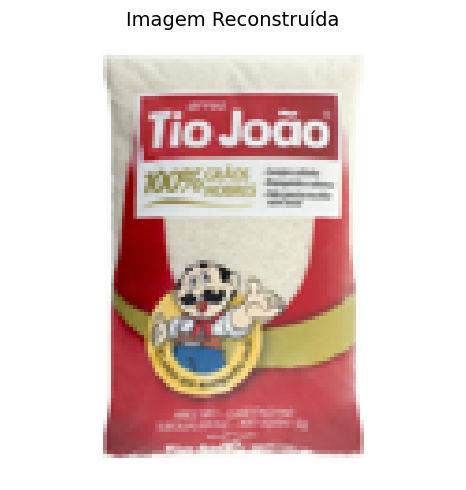

In [9]:
# ============================================================
# 7) TABELA -> MATRIZ -> IMAGEM
# ============================================================
def table_to_matrix(df):
    """
    Reconstrói a matriz (H×W×3) a partir do DataFrame de strings 'R,G,B'.
    """
    h, w = df.shape
    matrix_rec = np.zeros((h, w, 3), dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            r, g, b = map(int, str(df.iloc[y, x]).split(","))
            matrix_rec[y, x] = [r, g, b]
    return matrix_rec


def matrix_to_image(matrix):
    """Converte array NumPy de volta para objeto PIL Image."""
    return Image.fromarray(matrix.astype(np.uint8), mode="RGB")


# Lê o CSV exportado e reconstrói
df_lido = pd.read_csv("pixels.csv", header=None, dtype=str)
matrix_reconstruida = table_to_matrix(df_lido)
img_reconstruida = matrix_to_image(matrix_reconstruida)

# Salva a imagem reconstruída
img_reconstruida.save("imagem_reconstruida.png")
print("✅ Imagem reconstruída salva em: imagem_reconstruida.png")
plt.figure(figsize=(5, 5))
plt.imshow(img_reconstruida)
plt.title("Imagem Reconstruída", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()